# 第 12 章 · 真实图片去噪重建代码实验

本页把去噪任务单独拿出来看：给模型一张带噪建筑照片，让它输出更干净的图像。读者重点比较噪声输入和去噪输出的均方误差与视觉差异。

[章节网页](../ch12.html)

## 运行内容

- 加载真实图片图块
- 训练去噪模型
- 比较噪声输入和去噪输出

## 0. 去噪重建

把去噪任务单独拿出来看，可以帮助读者理解反向扩散中每一步都在学习的局部修复方向。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 真实建筑照片去噪：用同一张图片的局部图块训练复原模型。
denoise_clean = np.asarray(Image.fromarray(load_sample_image("china.jpg")).resize((96, 96))).astype("float32") / 255.0
denoise_patch_size = 12
denoise_stride = 6
patches_clean = []
patch_coords = []
for row in range(0, denoise_clean.shape[0] - denoise_patch_size + 1, denoise_stride):
    for col in range(0, denoise_clean.shape[1] - denoise_patch_size + 1, denoise_stride):
        patches_clean.append(denoise_clean[row:row + denoise_patch_size, col:col + denoise_patch_size].reshape(-1))
        patch_coords.append((row, col))
patches_clean = np.array(patches_clean)

rng = np.random.default_rng(19)
noise_sigma = 0.18
patches_noisy = np.clip(patches_clean + rng.normal(0, noise_sigma, patches_clean.shape), 0, 1)
patch_denoiser = MLPRegressor(hidden_layer_sizes=(160,), max_iter=180, random_state=19)
patch_denoiser.fit(patches_noisy, patches_clean)

noisy_image = np.clip(denoise_clean + rng.normal(0, noise_sigma, denoise_clean.shape), 0, 1)
noisy_image_patches = np.array([
    noisy_image[row:row + denoise_patch_size, col:col + denoise_patch_size].reshape(-1)
    for row, col in patch_coords
])
predicted = np.clip(patch_denoiser.predict(noisy_image_patches), 0, 1)

denoised_image = np.zeros_like(denoise_clean)
denoise_weight = np.zeros(denoise_clean.shape[:2] + (1,), dtype=float)
for (row, col), patch in zip(patch_coords, predicted):
    denoised_image[row:row + denoise_patch_size, col:col + denoise_patch_size] += patch.reshape(denoise_patch_size, denoise_patch_size, 3)
    denoise_weight[row:row + denoise_patch_size, col:col + denoise_patch_size] += 1
denoised_image = denoised_image / np.maximum(denoise_weight, 1)

denoise_summary = pd.DataFrame(
    [
        {"图像": "带噪输入", "均方误差": mean_squared_error(denoise_clean.reshape(-1), noisy_image.reshape(-1))},
        {"图像": "去噪输出", "均方误差": mean_squared_error(denoise_clean.reshape(-1), denoised_image.reshape(-1))},
    ]
)
display(pd.DataFrame({
    "图片": ["china.jpg"],
    "图块数": [len(patches_clean)],
    "噪声标准差": [noise_sigma],
}))
display(denoise_summary.round(4))

,图片,图块数,噪声标准差
0,china.jpg,225,0.18


,图像,均方误差
0,带噪输入,0.0244
1,去噪输出,0.0094


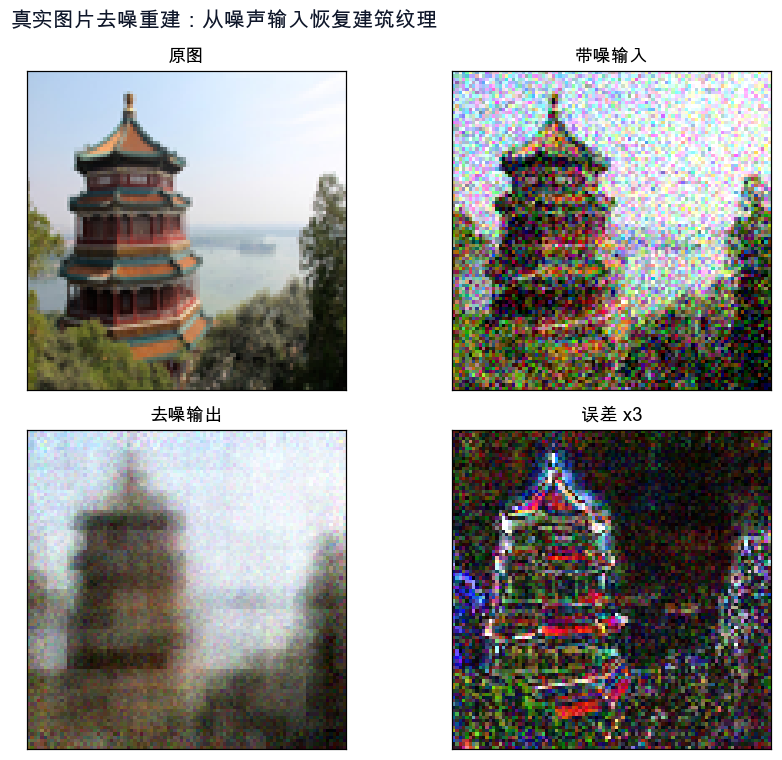

In [3]:
# 绘制真实图片、噪声输入和模型去噪输出。
fig, axes = plt.subplots(2, 2, figsize=(8.4, 7.0))
for ax, image, title in zip(
    axes.ravel(),
    [denoise_clean, noisy_image, denoised_image, np.abs(denoise_clean - denoised_image) * 3],
    ["原图", "带噪输入", "去噪输出", "误差 x3"],
):
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("真实图片去噪重建：从噪声输入恢复建筑纹理", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()